# Homework 5

Random X/Y Test 
Custom LS: m=0.15649568686824394, c=4.650310370765793
NumPy  LS: m=0.15649568686824464,  c=4.650310370765791


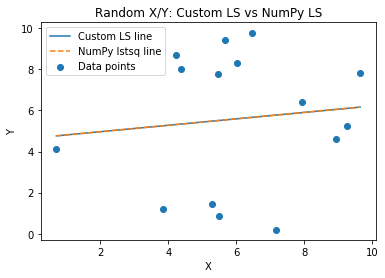


Noisy Line Test
True line:   y = 2.5x + -0.4
Custom LS:   y = 2.7860276995246496x + -0.5744111237863512
NumPy  LS:   y = 2.7860276995246496x + -0.5744111237863518

Residual report 
Largest residual at index 98: x=0.9800, y=1.0557, residual=-1.1002
Smallest residual at index 54: x=0.5400, y=0.9331, residual=0.0031


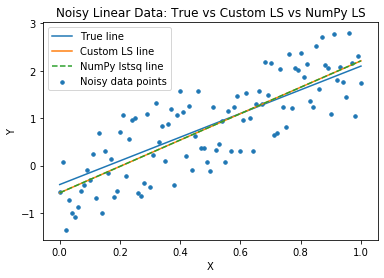

In [20]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

# ChatGPT Used to help break down instructions

def custom_least_squares_line(X, Y):
    A = np.vstack([X, np.ones(len(X))]).T  

    ATA = A.T @ A
    ATy = A.T @ Y

    m, c = np.linalg.solve(ATA, ATy)
    return m, c

def numpy_least_squares_line(X, Y):
    A = np.vstack([X, np.ones(len(X))]).T
    m, c = np.linalg.lstsq(A, Y, rcond=None)[0]
    return m, c

def residual_report(X, Y, Y_pred, label=""):
    residuals = Y - Y_pred

    i_max = np.argmax(np.abs(residuals))
    i_min = np.argmin(np.abs(residuals))

    print(f"\nResidual report {label}")
    print(f"Largest residual at index {i_max}: x={X[i_max]:.4f}, y={Y[i_max]:.4f}, residual={residuals[i_max]:.4f}")
    print(f"Smallest residual at index {i_min}: x={X[i_min]:.4f}, y={Y[i_min]:.4f}, residual={residuals[i_min]:.4f}")

    return residuals

np.random.seed(0)

n = 15
X_rand = np.random.rand(n) * 10
Y_rand = np.random.rand(n) * 10

order = np.argsort(X_rand) 
X1 = X_rand[order]
Y1 = Y_rand[order]

m_custom_1, c_custom_1 = custom_least_squares_line(X1, Y1)
m_numpy_1,  c_numpy_1  = numpy_least_squares_line(X1, Y1)

print("Random X/Y Test ")
print(f"Custom LS: m={m_custom_1}, c={c_custom_1}")
print(f"NumPy  LS: m={m_numpy_1},  c={c_numpy_1}")

Y1_pred_custom = m_custom_1 * X1 + c_custom_1
Y1_pred_numpy  = m_numpy_1  * X1 + c_numpy_1

plt.figure()
plt.scatter(X1, Y1, label="Data points")
plt.plot(X1, Y1_pred_custom, label="Custom LS line")
plt.plot(X1, Y1_pred_numpy,  label="NumPy lstsq line", linestyle="--")
plt.title("Random X/Y: Custom LS vs NumPy LS")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.show()


np.random.seed(1)

m_true = 2.5
b_true = -0.4

X2 = np.arange(0, 1.01, 0.01)

noise = (2 * np.random.rand(len(X2)) - 1)  # uniform in [-1, 1]
Y2 = m_true * X2 + b_true + noise

m_custom_2, c_custom_2 = custom_least_squares_line(X2, Y2)
m_numpy_2,  c_numpy_2  = numpy_least_squares_line(X2, Y2)

print("\nNoisy Line Test")
print(f"True line:   y = {m_true}x + {b_true}")
print(f"Custom LS:   y = {m_custom_2}x + {c_custom_2}")
print(f"NumPy  LS:   y = {m_numpy_2}x + {c_numpy_2}")


Y2_pred_custom = m_custom_2 * X2 + c_custom_2
Y2_pred_numpy  = m_numpy_2  * X2 + c_numpy_2

residuals_custom = residual_report(X2, Y2, Y2_pred_custom)

plt.figure()
plt.scatter(X2, Y2, s=12, label="Noisy data points")
plt.plot(X2, m_true * X2 + b_true, label="True line")
plt.plot(X2, Y2_pred_custom, label="Custom LS line")
plt.plot(X2, Y2_pred_numpy,  label="NumPy lstsq line", linestyle="--")
plt.title("Noisy Linear Data: True vs Custom LS vs NumPy LS")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.show()